In [ ]:
# تثبيت المكتبات المطلوبة
!pip install gymnasium[classic-control] torch numpy matplotlib

# اختبار أن كل شيء يعمل
import gymnasium as gym
import torch
import numpy as np

print("✅ تم تثبيت جميع المكتبات بنجاح")
print(f"إصدار PyTorch: {torch.__version__}")

✅ تم تثبيت جميع المكتبات بنجاح
إصدار PyTorch: 2.10.0+cpu


In [ ]:
# إنشاء البيئة
env = gym.make("CartPole-v1")

# تشغيل حلقة واحدة عشوائية (الوكيل لا يعرف شيئًا)
state, info = env.reset()
print(f"الحالة الأولية: {state}")
print(f"الحالة تحتوي على 4 قيم: [موضع العربة, سرعة العربة, زاوية العمود, سرعة العمود]")

done = False
total_reward = 0
step = 0

while not done:
    # اختيار فعل عشوائي (0 = يسار, 1 = يمين)
    action = env.action_space.sample()

    # تنفيذ الفعل في البيئة
    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    total_reward += reward
    step += 1

    print(f"الخطوة {step}: الفعل={action}, المكافأة={reward}, الحالة الجديدة={next_state[:2]}...")

print(f"\n🏁 انتهت الحلقة بعد {step} خطوة، إجمالي المكافأة={total_reward}")

# إغلاق البيئة
env.close()

الحالة الأولية: [-0.03312067 -0.0202213  -0.04639443 -0.0373048 ]
الحالة تحتوي على 4 قيم: [موضع العربة, سرعة العربة, زاوية العمود, سرعة العمود]
الخطوة 1: الفعل=0, المكافأة=1.0, الحالة الجديدة=[-0.03352509 -0.2146483 ]...
الخطوة 2: الفعل=1, المكافأة=1.0, الحالة الجديدة=[-0.03781806 -0.01888576]...
الخطوة 3: الفعل=1, المكافأة=1.0, الحالة الجديدة=[-0.03819578  0.17681675]...
الخطوة 4: الفعل=0, المكافأة=1.0, الحالة الجديدة=[-0.03465944 -0.01765851]...
الخطوة 5: الفعل=0, المكافأة=1.0, الحالة الجديدة=[-0.03501261 -0.21201193]...
الخطوة 6: الفعل=0, المكافأة=1.0, الحالة الجديدة=[-0.03925285 -0.40633705]...
الخطوة 7: الفعل=0, المكافأة=1.0, الحالة الجديدة=[-0.04737959 -0.60072786]...
الخطوة 8: الفعل=1, المكافأة=1.0, الحالة الجديدة=[-0.05939415 -0.40507427]...
الخطوة 9: الفعل=0, المكافأة=1.0, الحالة الجديدة=[-0.06749564 -0.59982586]...
الخطوة 10: الفعل=0, المكافأة=1.0, الحالة الجديدة=[-0.07949215 -0.7947095 ]...
الخطوة 11: الفعل=0, المكافأة=1.0, الحالة الجديدة=[-0.09538634 -0.989796  ]...
الخطوة 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

# تعيين رقم عشوائي ثابت للتكرار
torch.manual_seed(42)
random.seed(42)

# 1. تعريف الشبكة العصبية
class QNetwork(nn.Module):
    def __init__(self, state_size=4, action_size=2, hidden_size=64):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)   # طبقة مدخل → مخفي
        self.fc2 = nn.Linear(hidden_size, hidden_size)  # طبقة مخفي → مخفي
        self.fc3 = nn.Linear(hidden_size, action_size)  # طبقة مخفي → مخرج (قيم Q)

    def forward(self, x):
        x = torch.relu(self.fc1(x))   # تنشيط ReLU
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)                # لا نستخدم تنشيط في الطبقة الأخيرة
        return x

# اختبار الشبكة
test_network = QNetwork()
test_state = torch.randn(1, 4)  # حالة واحدة
q_values = test_network(test_state)
print(f"قيم Q لكل فعل: {q_values}")
print(f"الفعل المختار (أعلى قيمة Q): {torch.argmax(q_values).item()}")

قيم Q لكل فعل: tensor([[-0.1377, -0.2069]], grad_fn=<AddmmBackward0>)
الفعل المختار (أعلى قيمة Q): 0


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

# تعيين رقم عشوائي ثابت للتكرار
torch.manual_seed(42)
random.seed(42)

# 1. تعريف الشبكة العصبية
class QNetwork(nn.Module):
    def __init__(self, state_size=4, action_size=2, hidden_size=64):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)   # طبقة مدخل → مخفي
        self.fc2 = nn.Linear(hidden_size, hidden_size)  # طبقة مخفي → مخفي
        self.fc3 = nn.Linear(hidden_size, action_size)  # طبقة مخفي → مخرج (قيم Q)

    def forward(self, x):
        x = torch.relu(self.fc1(x))   # تنشيط ReLU
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)                # لا نستخدم تنشيط في الطبقة الأخيرة
        return x

# اختبار الشبكة
test_network = QNetwork()
test_state = torch.randn(1, 4)  # حالة واحدة
q_values = test_network(test_state)
print(f"قيم Q لكل فعل: {q_values}")
print(f"الفعل المختار (أعلى قيمة Q): {torch.argmax(q_values).item()}")
class DQNAgent:
    def __init__(self, state_size=4, action_size=2):
        self.state_size = state_size
        self.action_size = action_size

        # المعاملات الفائقة (Hyperparameters)
        self.gamma = 0.99          # معامل الخصم
        self.epsilon = 1.0         # معدل الاستكشاف (يبدأ 100%)
        self.epsilon_min = 0.01    # أقل معدل استكشاف
        self.epsilon_decay = 0.995 # سرعة تقليل الاستكشاف
        self.learning_rate = 0.001 # سرعة التعلم
        self.batch_size = 64       # حجم الدفعة
        self.memory_size = 10000   # حجم الذاكرة

        # الشبكات
        self.q_network = QNetwork(state_size, action_size)
        self.target_network = QNetwork(state_size, action_size)
        self.target_network.load_state_dict(self.q_network.state_dict())

        # المحسن (Optimizer)
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=self.learning_rate)

        # ذاكرة الخبرة (Replay Buffer)
        self.memory = deque(maxlen=self.memory_size)

    def act(self, state):
        """اختيار الفعل"""
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)  # استكشاف (عشوائي)

        # استغلال (اختيار أفضل فعل حسب الشبكة)
        state = torch.FloatTensor(state).unsqueeze(0)
        q_values = self.q_network(state)
        return torch.argmax(q_values).item()

    def remember(self, state, action, reward, next_state, done):
        """تخزين الخبرة"""
        self.memory.append((state, action, reward, next_state, done))

    def replay(self):
        """التدريب على عينات عشوائية من الذاكرة"""
        if len(self.memory) < self.batch_size:
            return

        # أخذ عينة عشوائية
        batch = random.sample(self.memory, self.batch_size)

        # تحويل إلى Tensors
        states = torch.FloatTensor([b[0] for b in batch])
        actions = torch.LongTensor([b[1] for b in batch])
        rewards = torch.FloatTensor([b[2] for b in batch])
        next_states = torch.FloatTensor([b[3] for b in batch])
        dones = torch.FloatTensor([b[4] for b in batch])

        # حساب قيم Q الحالية
        current_q = self.q_network(states).gather(1, actions.unsqueeze(1))

        # حساب قيم Q المستهدفة
        with torch.no_grad():
            next_q = self.target_network(next_states).max(1)[0]
            target_q = rewards + (1 - dones) * self.gamma * next_q

        # حساب الخسارة
        loss = nn.MSELoss()(current_q.squeeze(), target_q)

        # تحديث الشبكة
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_target_network(self):
        """نسخ أوزان الشبكة الرئيسية إلى الشبكة الهدف"""
        self.target_network.load_state_dict(self.q_network.state_dict())

    def decay_epsilon(self):
        """تقليل معدل الاستكشاف"""
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

قيم Q لكل فعل: tensor([[-0.1377, -0.2069]], grad_fn=<AddmmBackward0>)
الفعل المختار (أعلى قيمة Q): 0


/tmp/ipykernel_13095/4145245081.py:79: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.FloatTensor([b[0] for b in batch])


الحلقة 50/500 | متوسط آخر 50 حلقة: 26.52 | معدل الاستكشاف: 0.778
الحلقة 100/500 | متوسط آخر 50 حلقة: 46.46 | معدل الاستكشاف: 0.606
الحلقة 150/500 | متوسط آخر 50 حلقة: 73.56 | معدل الاستكشاف: 0.471
الحلقة 200/500 | متوسط آخر 50 حلقة: 78.90 | معدل الاستكشاف: 0.367
الحلقة 250/500 | متوسط آخر 50 حلقة: 121.46 | معدل الاستكشاف: 0.286
الحلقة 300/500 | متوسط آخر 50 حلقة: 139.46 | معدل الاستكشاف: 0.222
الحلقة 350/500 | متوسط آخر 50 حلقة: 153.16 | معدل الاستكشاف: 0.173
الحلقة 400/500 | متوسط آخر 50 حلقة: 294.66 | معدل الاستكشاف: 0.135
الحلقة 450/500 | متوسط آخر 50 حلقة: 236.64 | معدل الاستكشاف: 0.105
الحلقة 500/500 | متوسط آخر 50 حلقة: 170.94 | معدل الاستكشاف: 0.082


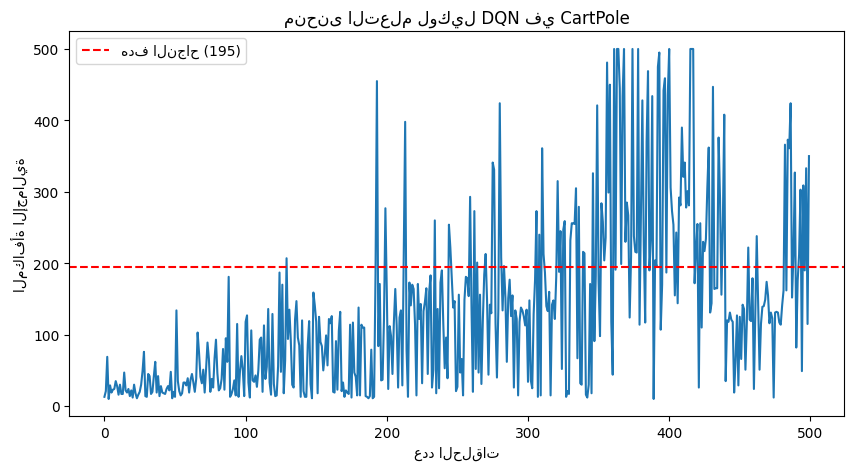


📊 النتائج النهائية:
أفضل نتيجة: 500.0
متوسط آخر 100 حلقة: 203.79


In [ ]:
import matplotlib.pyplot as plt

# إنشاء الوكيل والبيئة
agent = DQNAgent()
env = gym.make("CartPole-v1")

# لتسجيل النتائج
episode_rewards = []
episodes = 500  # عدد حلقات التدريب

for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False

    while not done:
        # اختيار الفعل
        action = agent.act(state)

        # تنفيذ الفعل
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # تخزين الخبرة
        agent.remember(state, action, reward, next_state, done)

        # التدريب
        agent.replay()

        # التحديث
        state = next_state
        total_reward += reward

    # تسجيل النتيجة
    episode_rewards.append(total_reward)

    # تقليل الاستكشاف
    agent.decay_epsilon()

    # تحديث الشبكة الهدف كل 10 حلقات
    if episode % 10 == 0:
        agent.update_target_network()

    # عرض التقدم
    if (episode + 1) % 50 == 0:
        avg_reward = sum(episode_rewards[-50:]) / 50
        print(f"الحلقة {episode+1}/{episodes} | متوسط آخر 50 حلقة: {avg_reward:.2f} | معدل الاستكشاف: {agent.epsilon:.3f}")

env.close()

# رسم النتائج
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards)
plt.xlabel('عدد الحلقات')
plt.ylabel('المكافأة الإجمالية')
plt.title('منحنى التعلم لوكيل DQN في CartPole')
plt.axhline(y=195, color='r', linestyle='--', label='هدف النجاح (195)')
plt.legend()
plt.show()

print(f"\n📊 النتائج النهائية:")
print(f"أفضل نتيجة: {max(episode_rewards)}")
print(f"متوسط آخر 100 حلقة: {sum(episode_rewards[-100:])/100:.2f}")

In [ ]:
# وضع الوكيل في وضع التقييم (لا استكشاف)
agent.epsilon = 0

test_episodes = 50
test_rewards = []

for episode in range(test_episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False

    while not done:
        action = agent.act(state)
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward

    test_rewards.append(total_reward)
    print(f"اختبار {episode+1}: {total_reward} خطوة")

print(f"\n📊 نتائج التقييم:")
print(f"المتوسط: {np.mean(test_rewards):.2f}")
print(f"الانحراف المعياري: {np.std(test_rewards):.2f}")
print(f"أدنى نتيجة: {min(test_rewards)}")
print(f"أعلى نتيجة: {max(test_rewards)}")

if np.mean(test_rewards) >= 195:
    print("✅ نجح الوكيل! حل المشكلة")
else:
    print("❌ لم ينجح الوكيل بعد، يحتاج تدريبًا أطول")

اختبار 1: 150.0 خطوة
اختبار 2: 164.0 خطوة
اختبار 3: 163.0 خطوة
اختبار 4: 180.0 خطوة
اختبار 5: 209.0 خطوة
اختبار 6: 187.0 خطوة
اختبار 7: 159.0 خطوة
اختبار 8: 157.0 خطوة
اختبار 9: 177.0 خطوة
اختبار 10: 173.0 خطوة
اختبار 11: 191.0 خطوة
اختبار 12: 192.0 خطوة
اختبار 13: 150.0 خطوة
اختبار 14: 171.0 خطوة
اختبار 15: 163.0 خطوة
اختبار 16: 163.0 خطوة
اختبار 17: 162.0 خطوة
اختبار 18: 180.0 خطوة
اختبار 19: 203.0 خطوة
اختبار 20: 172.0 خطوة
اختبار 21: 165.0 خطوة
اختبار 22: 141.0 خطوة
اختبار 23: 165.0 خطوة
اختبار 24: 158.0 خطوة
اختبار 25: 176.0 خطوة
اختبار 26: 155.0 خطوة
اختبار 27: 178.0 خطوة
اختبار 28: 167.0 خطوة
اختبار 29: 151.0 خطوة
اختبار 30: 170.0 خطوة
اختبار 31: 172.0 خطوة
اختبار 32: 158.0 خطوة
اختبار 33: 154.0 خطوة
اختبار 34: 160.0 خطوة
اختبار 35: 147.0 خطوة
اختبار 36: 155.0 خطوة
اختبار 37: 174.0 خطوة
اختبار 38: 156.0 خطوة
اختبار 39: 158.0 خطوة
اختبار 40: 149.0 خطوة
اختبار 41: 166.0 خطوة
اختبار 42: 163.0 خطوة
اختبار 43: 179.0 خطوة
اختبار 44: 193.0 خطوة
اختبار 45: 166.0 خطوة
اختبار 46: 156.0 خط